# Word Embeddings

Any task aimed at processing language must first begin with focusing on how to represent the words essentially. A preliminary method is a "bag of words" mdoel which encodes words using a one-hot scheme. However due to their inability to represent semantic and syntactic relationships between words- they are encoded as individual its in a vector space and there is no way you can tell the words "love" and "like" have a similar connection.

Word embeddings are basically representations where contexts and similarities are captured by encoding in a vector space - simliar words have similar representations.

### Word2Vec

Word2Vec creates representation of each word present in our vocabulary into a vector. Words with similar context/semantic relationships are captured effectively through their closeness in vector space effectively speaking similar words will have similar word vectors.

Except the fact that the criterion we have used for each of the words are not clearly determinable. What matters to us is the semantic and syntactic relations between words which can still be determined by our model without explicitly having defining features for units of the vector. Embeddings generated by word2vec can further be used in NLP tasks, such as using it as an input to a CNN to classify text.

Word2Vec is a shallow 2-layer neural network.

- Input contains all the documents/texts in our training set. For the network to process these texts, they are represented in a 1-hot encoding of words.

- Neurons present in the hidden layer is equal to the length of the embedding we want. If we want all our word to be vectors of length 300, then hidden layer will contain 300 neurons.

- The output layer contains probabilities for a target word (given an input to the model, what word is expected) given a particular input.

- At the end of the training process, the hidden weights are treated as word embeddings. Intuitively, this can be thought of as each word having n weights (300 considering the example above) weighing their different characteristics.

![word embedding representation](./word_embedding.png)

There are two ways to develop these embeddings:

1. CBOW (Continuous Bag-Of-Words)
1. Skipgram

1. CBOW

CBOW predicts the target-word based on its surrounding words. For example, in the sentence "The cake was chocolate flavoured.", the model will iterate over this sentence for different target words, such as: 

"The ___ was chocolate flavoured" being inputs and "cake" being the target word.

CBOW smooths over the distribution of the information as it treats the entire context as one observation. CBOW is a faster algorithm than skipgrams and works well with frequent words.

1. Skipgram

Skipgram works in the exact opposite way to CBOW. Here, we take input word and expect the model to tell us what words it is expected to be surrounded by. Taking the same example, with “cake” we would expect the model to give us “The”, “was”, “chocolate”, “flavoured” for the given instance. The statistical interpretation of this is that we treat each context-target pair as a new observation. Skipgrams work well with small datasets and can better represent less frequent words.

### Using Gensim to train our own embeddings

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
dataset = pd.read_csv("Corona_NLP_train.csv", encoding="latin1")
dataset.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [9]:
import re

texts = []
for i in range(0, len(dataset)):
    text = re.sub('[^a-zA-Z]', ' ', dataset['OriginalTweet'][i])
    text.lower()
    text = text.split()
    x = len(text) if text.count('https') == 0 else text.index("https")
    text = text[: x]
    text = [t for t in text if not t == 'https']
    text = ' '.join(text)
    texts.append(text)

In [10]:
print(len(texts))

41157


### word2vec training

In [11]:
from gensim.models import Word2Vec

In [14]:
sentences = [line.split() for line in texts]

w2v = Word2Vec(sentences, vector_size=100, window=5, workers=4, epochs=10, min_count=5)

In [15]:
print(sentences[20:25])

[['with', 'nations', 'inficted', 'with', 'covid', 'the', 'world', 'must', 'not', 'play', 'fair', 'with', 'china', 'goverments', 'must', 'demand', 'china', 'adopts', 'new', 'guilde', 'lines', 'on', 'food', 'safty', 'the', 'chinese', 'goverment', 'is', 'guilty', 'of', 'being', 'irosponcible', 'with', 'life', 'on', 'a', 'global', 'scale'], [], ['We', 'have', 'AMAZING', 'CHEAP', 'DEALS', 'FOR', 'THE', 'COVID', 'going', 'on', 'to', 'help', 'you', 'Trials', 'Monthly', 'Yearly', 'And', 'Resonable', 'Prices', 'Subscriptions', 'Just', 'DM', 'US', 'bestiptv', 'iptv', 'Service', 'Iptv', 'iptvdeals', 'Cheap', 'ipTV', 'Football', 'HD', 'Movies', 'Adult', 'Cinema', 'hotmovies', 'iptvnew', 'iptv', 'Adult'], ['We', 'have', 'AMAZING', 'CHEAP', 'DEALS', 'FOR', 'THE', 'COVID', 'going', 'on', 'to', 'help', 'you', 'Trials', 'Monthly', 'Yearly', 'And', 'Resonable', 'Prices', 'Subscriptions', 'Just', 'DM', 'US', 'bestiptv', 'iptv', 'Service', 'Iptv', 'iptvdeals', 'Cheap', 'ipTV', 'Football', 'HD', 'Movies', 

### working with word2vec

In [17]:
words = list(w2v.wv.key_to_index)

In [18]:
print(words)

['the', 'to', 'and', 'of', 'a', 'in', 'COVID', 'for', 'coronavirus', 'is', 'are', 'I', 'on', 'you', 's', 'at', 'prices', 'store', 'that', 'this', 'supermarket', 'food', 'with', 'have', 'it', 'grocery', 'be', 'Covid', 't', 'as', 'amp', 'from', 'people', 'we', 'all', 'your', 'The', 'will', 'can', 'not', 'out', 'up', 'has', 'by', 'or', 'our', 'they', 'my', 'shopping', 'more', 'consumer', 'their', 'online', 'during', 'but', 'Coronavirus', 'pandemic', 'about', 'covid', 'get', 'We', 'now', 'need', 'who', 'workers', 'panic', 'how', 'so', 'like', 'was', 'time', 'an', 'go', 'no', 'demand', 'home', 'do', 'if', 'help', 're', 'what', 'sanitizer', 'just', 'some', 'going', 'stock', 'there', 'been', 'm', 'when', 'me', 'hand', 'buying', 'It', 'This', 'one', 'us', 'due', 'work', 'them', 'crisis', 'don', 'If', 'other', 'than', 'A', 'because', 'over', 'Consumer', 'oil', 'should', 'local', 'paper', 'only', 'after', 'toilet', 'shelves', 'toiletpaper', 'here', 'being', 'stores', 'buy', 'these', 'down', 'sti

In [19]:
print(len(words))

12787


In [20]:
print(w2v.wv['computer'])

[-0.15429814  0.09308865 -0.02380705  0.13518593 -0.12030456 -0.18880527
 -0.00600804 -0.00828195 -0.2799353   0.13346416 -0.05959455 -0.2984259
  0.41972357  0.20069064 -0.18981548 -0.21067591  0.01792682 -0.42514062
 -0.11967639 -0.34199837  0.12139256  0.07384297  0.14092045  0.06892528
 -0.10434213 -0.17723626 -0.16484946  0.05580745  0.06290905  0.16504759
  0.22086406 -0.11020618  0.03532438  0.0467661  -0.08854237  0.14979604
 -0.16144684 -0.130165    0.10692869 -0.159508   -0.04338972 -0.16166754
  0.09522731  0.18033834  0.09632768  0.03772435 -0.12739415  0.17727225
 -0.03549263  0.30051306  0.2015772   0.05562013 -0.14262785 -0.04129823
 -0.0833738   0.14135605  0.06395389  0.04143858 -0.00403063  0.06490857
 -0.31633765  0.18012328 -0.2996372   0.04937809 -0.2632569  -0.02112691
 -0.01392011  0.22582966  0.03641678  0.00742724 -0.07339767 -0.05229854
  0.36766946 -0.13554244  0.06819959  0.16928436  0.01620461 -0.1277954
 -0.17736171  0.2042075  -0.00327896 -0.06750029 -0.1

In [26]:
w2v.wv.similarity('coronavirus', 'COVID')

np.float32(0.5133905)

In [27]:
w2v.wv.most_similar('pay')

[('wages', 0.7009074687957764),
 ('paid', 0.6805514097213745),
 ('bills', 0.6307575106620789),
 ('rent', 0.6244909763336182),
 ('raise', 0.6207500696182251),
 ('paying', 0.6185199618339539),
 ('tax', 0.6040259003639221),
 ('wage', 0.5954858064651489),
 ('leave', 0.5947720408439636),
 ('receive', 0.5879026055335999)]

In [28]:
w2v.wv.most_similar('covid')

[('Covid', 0.6478456854820251),
 ('COVID', 0.6104946136474609),
 ('virus', 0.5389806628227234),
 ('corona', 0.5128988027572632),
 ('coronavirus', 0.4992600679397583),
 ('Corvid', 0.4843461811542511),
 ('socialdistancing', 0.47399240732192993),
 ('quarantine', 0.45600172877311707),
 ('staysafe', 0.4302006661891937),
 ('CoronaCrisis', 0.42949163913726807)]

In [31]:
w2v.wv.most_similar('hello')

[('hilarious', 0.79982590675354),
 ('theage', 0.7974846363067627),
 ('genius', 0.7844030857086182),
 ('SEE', 0.7815876007080078),
 ('ATTENTION', 0.7736126780509949),
 ('pig', 0.7733447551727295),
 ('Nancy', 0.7724180817604065),
 ('ABSOLUTELY', 0.7720513939857483),
 ('Bernie', 0.7666844725608826),
 ('GUYS', 0.7649734020233154)]

In [33]:
for i in words:
    print(i)

the
to
and
of
a
in
COVID
for
coronavirus
is
are
I
on
you
s
at
prices
store
that
this
supermarket
food
with
have
it
grocery
be
Covid
t
as
amp
from
people
we
all
your
The
will
can
not
out
up
has
by
or
our
they
my
shopping
more
consumer
their
online
during
but
Coronavirus
pandemic
about
covid
get
We
now
need
who
workers
panic
how
so
like
was
time
an
go
no
demand
home
do
if
help
re
what
sanitizer
just
some
going
stock
there
been
m
when
me
hand
buying
It
This
one
us
due
work
them
crisis
don
If
other
than
A
because
over
Consumer
oil
should
local
paper
only
after
toilet
shelves
toiletpaper
here
being
stores
buy
these
down
still
keep
delivery
new
In
many
know
make
those
today
ve
into
You
retail
outbreak
see
would
supply
staff
its
How
day
had
take
lockdown
could
week
working
masks
any
essential
What
virus
social
were
stay
even
price
spread
They
everyone
health
customers
UK
Food
way
also
My
think
amid
employees
As
safe
world
off
shop
So
items
market
Please
business
much
back
use
Supermarket
am
d

In [34]:
w2v.wv.most_similar(positive=['supermarket', 'food'], negative=['judged'])

[('supermarkets', 0.6153740286827087),
 ('essentials', 0.5020387172698975),
 ('milk', 0.46651020646095276),
 ('trucks', 0.46518605947494507),
 ('grocery', 0.4461382329463959),
 ('foods', 0.4402981698513031),
 ('fresh', 0.4387076199054718),
 ('groceries', 0.4374285936355591),
 ('meal', 0.4291622042655945),
 ('shop', 0.4283645451068878)]

In [35]:
w2v.wv.doesnt_match(['grocery', 'covid', 'coronavirus'])

'grocery'

In [36]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def display_pca_scatterplot(model, words=None, sample=0):
    if words == None:
        if sample > 0:
            words = np.random.choice(list(model.vocab.keys()), sample)
        else:
            words = [word for word in model.vocab]
    
    word_vectors = np.array([model[w] for w in words])

    twodim = PCA().fit_transform(word_vectors)[:, :2]

    plt.figure(figsize=(6, 6))
    plt.scatter(twodim[:, 0], twodim[:, 1], edgecolors='k', c='r')
    for word, (x, y) in zip(words, twodim):
        plt.text(x+0.05, y+0.05, word)

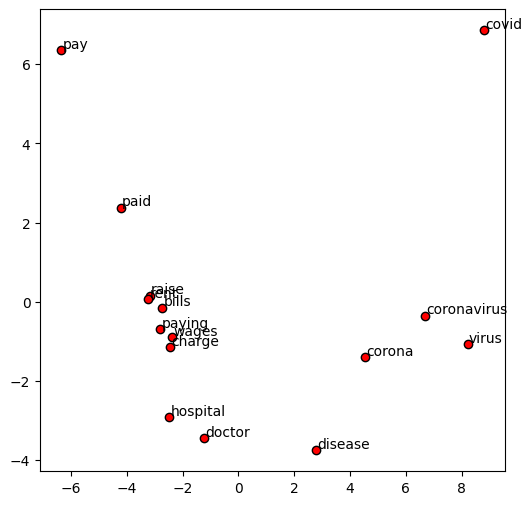

In [40]:
display_pca_scatterplot(w2v.wv ,['coronavirus', 'covid', 'virus', 'corona','disease',  'doctor', 'hospital', 'pay', 'paying', 'paid', 'wages', 'raise', 'bills', 'rent', 'charge']  )

### Exporting pre trained embeddings + Saving/Loading our model

In [41]:
import gensim.downloader
print(list(gensim.downloader.info()['models'].keys()))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


In [42]:
google_news = gensim.downloader.load('word2vec-google-news-300')
google_news.most_similar('twitter')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


[('Twitter', 0.8908904194831848),
 ('Twitter.com', 0.7536780834197998),
 ('tweet', 0.7431626319885254),
 ('tweeting', 0.7161932587623596),
 ('tweeted', 0.7137226462364197),
 ('facebook', 0.6988551616668701),
 ('tweets', 0.6974530816078186),
 ('Tweeted', 0.6950210928916931),
 ('Tweet', 0.6875007152557373),
 ('Tweeting', 0.6845167279243469)]

In [43]:
w2v.save("word2vec.model")

In [44]:
model = Word2Vec.load("word2vec.model")
model.train([["hello", "world"]], total_examples=1, epochs=1)

(2, 2)